# 0. Handle Missing Values

This notebook performs the following steps:
1. Load the raw dataset
2. Inspect dataset structure (shape, dtypes, info, describe)
3. Check for missing values
4. Check for duplicate rows
5. Handle missing values (imputation strategy)
6. Verify the cleaned dataset
7. Save the processed data to `dataset/processed/`

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

# Notebook display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load the Raw Dataset

In [2]:
RAW_PATH = 'C:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system/dataset/raw/credit_card_fraud_10k.csv'

RAW_PATH = 'C:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system/dataset/raw/credit_card_fraud_10k.csv'
df = pd.read_csv(RAW_PATH)

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(10)

Dataset loaded: 10,000 rows × 10 columns


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.4700,22,Electronics,0,0,66,3,40,0
1,2,541.8200,3,Travel,1,0,87,1,64,0
2,3,237.0100,17,Grocery,0,0,49,1,61,0
3,4,164.3300,4,Grocery,0,1,72,3,34,0
4,5,30.5300,15,Food,0,0,79,0,44,0
5,6,30.5300,13,Clothing,0,0,90,2,46,0
6,7,10.7700,18,Travel,0,0,48,1,28,0
7,8,362.0200,13,Electronics,0,0,68,1,40,0
8,9,165.4300,8,Grocery,0,0,80,0,21,0
9,10,221.6300,5,Grocery,0,0,59,1,34,0


## Feature Descriptions

| Feature | Description |
|---|---|
| `transaction_id` | Unique identifier for each transaction |
| `amount` | Transaction amount |
| `transaction_hour` | Hour of transaction (0–23) |
| `merchant_category` | Type of merchant |
| `foreign_transaction` | Indicates if transaction is international (0/1) |
| `location_mismatch` | Billing vs transaction location mismatch (0/1) |
| `device_trust_score` | Trust score of the device (0–100) |
| `velocity_last_24h` | Number of transactions in last 24 hours |
| `cardholder_age` | Age of the cardholder |
| `is_fraud` | Target variable — 1 if fraudulent, 0 otherwise |

## 2. Dataset Structure & Basic Statistics

In [3]:
# Shape and column names
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())

Shape: (10000, 10)

Columns: ['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [ ]:
# Statistical summary of numerical features
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5000.5000,175.9498,11.5933,0.0978,0.0857,61.7989,2.0089,43.4687,0.0151
std,2886.8957,175.3928,6.9227,0.2971,0.2799,21.4871,1.4326,14.9791,0.1220
min,1.0000,0.0000,0.0000,0.0000,0.0000,25.0000,0.0000,18.0000,0.0000
25%,2500.7500,50.9050,6.0000,0.0000,0.0000,43.0000,1.0000,30.0000,0.0000
50%,5000.5000,122.0950,12.0000,0.0000,0.0000,62.0000,2.0000,44.0000,0.0000
75%,7500.2500,242.4800,18.0000,0.0000,0.0000,80.0000,3.0000,56.0000,0.0000
max,10000.0000,1471.0400,23.0000,1.0000,1.0000,99.0000,9.0000,69.0000,1.0000


In [6]:
# Categorical column — unique values
print('merchant_category unique values:', df['merchant_category'].unique())

merchant_category unique values: <StringArray>
['Electronics', 'Travel', 'Grocery', 'Food', 'Clothing']
Length: 5, dtype: str


## 3. Check for Missing Values

In [8]:
# Count of missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})
print(missing_df)
print(f'\nTotal missing values: {missing.sum()}')

                     Missing Count  Missing %
transaction_id                   0     0.0000
amount                           0     0.0000
transaction_hour                 0     0.0000
merchant_category                0     0.0000
foreign_transaction              0     0.0000
location_mismatch                0     0.0000
device_trust_score               0     0.0000
velocity_last_24h                0     0.0000
cardholder_age                   0     0.0000
is_fraud                         0     0.0000

Total missing values: 0


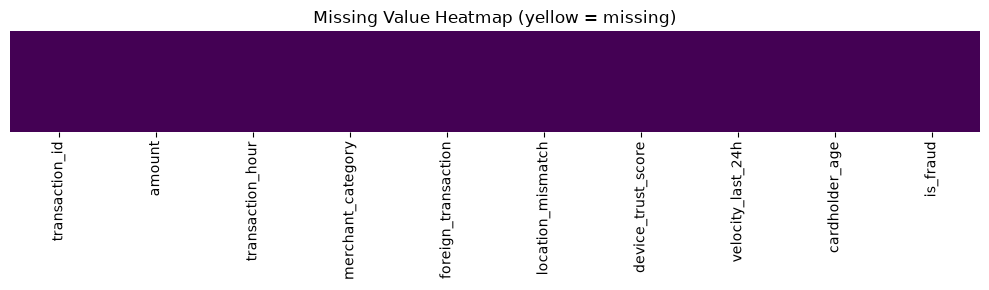

In [9]:
# Visualise missing values as a heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (yellow = missing)')
plt.tight_layout()
plt.show()

## 4. Check for Duplicate Rows

In [10]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    print('Dropping duplicate rows...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Shape after removing duplicates: {df.shape}')
else:
    print('No duplicates found — dataset is clean.')

Number of duplicate rows: 0
No duplicates found — dataset is clean.


## 5. Handle Missing Values

**Strategy:**
- **Numerical columns** (continuous): fill with **median** (robust to outliers)
- **Numerical columns** (binary/integer flags): fill with **mode** (most frequent value)
- **Categorical columns**: fill with **mode** (most frequent category)

> If there are 0 missing values, this step is a no-op but documents the handling strategy for future data.

In [11]:
# Define column types
numerical_continuous = ['amount', 'device_trust_score', 'cardholder_age']
numerical_binary     = ['foreign_transaction', 'location_mismatch', 'is_fraud']
numerical_count      = ['transaction_hour', 'velocity_last_24h']
categorical_cols     = ['merchant_category']

# --- Fill continuous numerical with median ---
for col in numerical_continuous:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  [{col}] filled {df[col].isnull().sum()} NaNs with median={median_val}')

# --- Fill binary / count numerical with mode ---
for col in numerical_binary + numerical_count:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  [{col}] filled {df[col].isnull().sum()} NaNs with mode={mode_val}')

# --- Fill categorical with mode ---
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'  [{col}] filled {df[col].isnull().sum()} NaNs with mode="{mode_val}"')

print('\nMissing value handling complete.')


Missing value handling complete.


## 6. Verify Cleaned Dataset

In [12]:
# Re-check missing values
remaining_missing = df.isnull().sum().sum()
print(f'Remaining missing values after handling: {remaining_missing}')

assert remaining_missing == 0, 'There are still missing values!'
print('All missing values resolved.')

Remaining missing values after handling: 0
All missing values resolved.


In [13]:
# Class balance check
print('Class distribution (is_fraud):')
print(df['is_fraud'].value_counts())
print(f'\nFraud rate: {df["is_fraud"].mean()*100:.2f}%')

Class distribution (is_fraud):
is_fraud
0    9849
1     151
Name: count, dtype: int64

Fraud rate: 1.51%


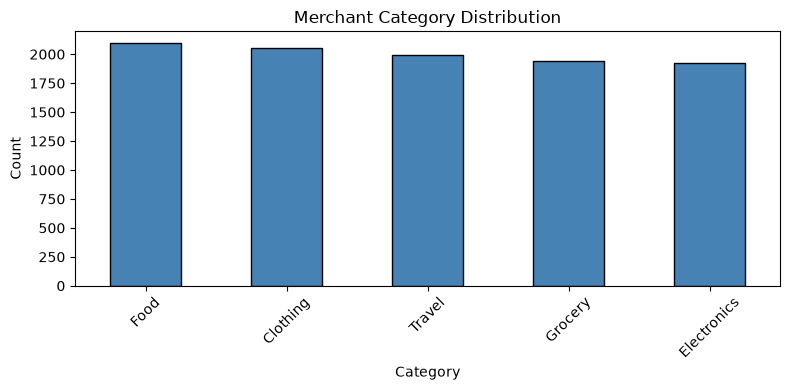

In [15]:
# Distribution of merchant_category
plt.figure(figsize=(8, 4))
df['merchant_category'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Merchant Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
# Final dataset preview
print('Final dataset shape:', df.shape)
df.head()

Final dataset shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.4700,22,Electronics,0,0,66,3,40,0
1,2,541.8200,3,Travel,1,0,87,1,64,0
2,3,237.0100,17,Grocery,0,0,49,1,61,0
3,4,164.3300,4,Grocery,0,1,72,3,34,0
4,5,30.5300,15,Food,0,0,79,0,44,0


## 7. Save Processed Data

In [20]:
processed_dir = 'C:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system/dataset/processed'
os.makedirs(processed_dir, exist_ok=True)

output_path = os.path.join(processed_dir, 'credit_card_fraud_null_handled.csv')
df.to_csv(output_path, index=False)

print(f'Processed data saved to: {output_path}')
print(f'Shape: {df.shape}')

# Verify the file was written
import os
file_size_kb = os.path.getsize(output_path) / 1024
print(f'File size: {file_size_kb:.1f} KB')

Processed data saved to: C:/Users/2021ICTS28/Desktop/end-to-end-credit-card-fraud-detection-system/dataset/processed\credit_card_fraud_null_handled.csv
Shape: (10000, 10)
File size: 361.8 KB
